In [1]:
import pandas as pd
import numpy as np

fraud_df = pd.read_csv("../data/raw/paysim/PS_20174392719_1491204439457_log.csv")

fraud_df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [2]:
fraud_df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [3]:
customer_features = fraud_df.groupby("nameOrig").agg(
    total_transactions=("step", "count"),
    total_amount=("amount", "sum"),
    avg_amount=("amount", "mean"),
    max_amount=("amount", "max"),
    min_amount=("amount", "min"),
    total_fraud_transactions=("isFraud", "sum"),
    fraud_ratio=("isFraud", "mean"),
    avg_old_balance=("oldbalanceOrg", "mean"),
    avg_new_balance=("newbalanceOrig", "mean"),
    max_old_balance=("oldbalanceOrg", "max"),
    max_new_balance=("newbalanceOrig", "max")
).reset_index()

customer_features.head()

,nameOrig,total_transactions,total_amount,avg_amount,max_amount,min_amount,total_fraud_transactions,fraud_ratio,avg_old_balance,avg_new_balance,max_old_balance,max_new_balance
0,C1000000639,1,244486.46,244486.46,244486.46,244486.46,0,0.0,8946.00,0.00,8946.00,0.00
1,C1000001337,1,3170.28,3170.28,3170.28,3170.28,0,0.0,58089.00,54918.72,58089.00,54918.72
2,C1000001725,1,8424.74,8424.74,8424.74,8424.74,0,0.0,783.00,0.00,783.00,0.00
3,C1000002591,1,261877.19,261877.19,261877.19,261877.19,0,0.0,7596.00,269473.19,7596.00,269473.19
4,C1000003372,1,20528.65,20528.65,20528.65,20528.65,0,0.0,2302074.12,2322602.77,2302074.12,2322602.77


In [4]:
transaction_type_features = pd.crosstab(
    fraud_df["nameOrig"],
    fraud_df["type"]
).reset_index()

transaction_type_features.head()

type,nameOrig,CASH_IN,CASH_OUT,DEBIT,PAYMENT,TRANSFER
0,C1000000639,0,1,0,0,0
1,C1000001337,0,0,0,1,0
2,C1000001725,0,0,0,1,0
3,C1000002591,1,0,0,0,0
4,C1000003372,1,0,0,0,0


In [5]:
customer_features = customer_features.merge(
    transaction_type_features,
    on="nameOrig",
    how="left"
)

customer_features.head()

,nameOrig,total_transactions,total_amount,avg_amount,max_amount,min_amount,total_fraud_transactions,fraud_ratio,avg_old_balance,avg_new_balance,max_old_balance,max_new_balance,CASH_IN,CASH_OUT,DEBIT,PAYMENT,TRANSFER
0,C1000000639,1,244486.46,244486.46,244486.46,244486.46,0,0.0,8946.00,0.00,8946.00,0.00,0,1,0,0,0
1,C1000001337,1,3170.28,3170.28,3170.28,3170.28,0,0.0,58089.00,54918.72,58089.00,54918.72,0,0,0,1,0
2,C1000001725,1,8424.74,8424.74,8424.74,8424.74,0,0.0,783.00,0.00,783.00,0.00,0,0,0,1,0
3,C1000002591,1,261877.19,261877.19,261877.19,261877.19,0,0.0,7596.00,269473.19,7596.00,269473.19,1,0,0,0,0
4,C1000003372,1,20528.65,20528.65,20528.65,20528.65,0,0.0,2302074.12,2322602.77,2302074.12,2322602.77,1,0,0,0,0


In [6]:
import os

os.makedirs("../data/processed", exist_ok=True)

customer_features.to_csv("../data/processed/customer_segmentation_base.csv", index=False)

print("Customer segmentation base file saved successfully!")
print(customer_features.shape)

Customer segmentation base file saved successfully!
(6353307, 17)


In [7]:
seg_df = customer_features.copy()

customer_ids = seg_df["nameOrig"]

X = seg_df.drop(["nameOrig", "total_fraud_transactions", "fraud_ratio"], axis=1)

X.head()

,total_transactions,total_amount,avg_amount,max_amount,min_amount,avg_old_balance,avg_new_balance,max_old_balance,max_new_balance,CASH_IN,CASH_OUT,DEBIT,PAYMENT,TRANSFER
0,1,244486.46,244486.46,244486.46,244486.46,8946.00,0.00,8946.00,0.00,0,1,0,0,0
1,1,3170.28,3170.28,3170.28,3170.28,58089.00,54918.72,58089.00,54918.72,0,0,0,1,0
2,1,8424.74,8424.74,8424.74,8424.74,783.00,0.00,783.00,0.00,0,0,0,1,0
3,1,261877.19,261877.19,261877.19,261877.19,7596.00,269473.19,7596.00,269473.19,1,0,0,0,0
4,1,20528.65,20528.65,20528.65,20528.65,2302074.12,2322602.77,2302074.12,2322602.77,1,0,0,0,0


In [8]:
X.isnull().sum()

total_transactions    0
total_amount          0
avg_amount            0
max_amount            0
min_amount            0
avg_old_balance       0
avg_new_balance       0
max_old_balance       0
max_new_balance       0
CASH_IN               0
CASH_OUT              0
DEBIT                 0
PAYMENT               0
TRANSFER              0
dtype: int64

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

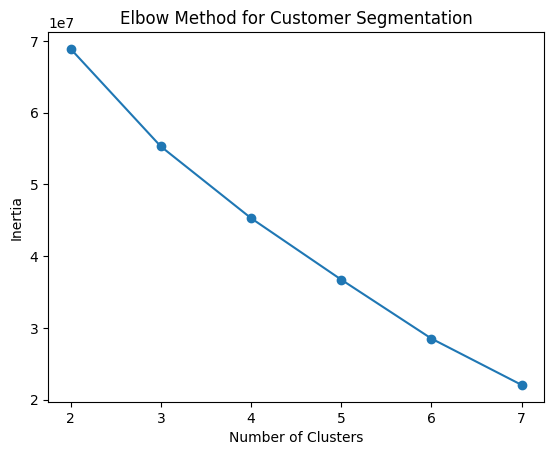

In [10]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Customer Segmentation")
plt.show()

In [11]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

seg_df["customer_segment"] = kmeans.fit_predict(X_scaled)

seg_df.head()

,nameOrig,total_transactions,total_amount,avg_amount,max_amount,min_amount,total_fraud_transactions,fraud_ratio,avg_old_balance,avg_new_balance,max_old_balance,max_new_balance,CASH_IN,CASH_OUT,DEBIT,PAYMENT,TRANSFER,customer_segment
0,C1000000639,1,244486.46,244486.46,244486.46,244486.46,0,0.0,8946.00,0.00,8946.00,0.00,0,1,0,0,0,1
1,C1000001337,1,3170.28,3170.28,3170.28,3170.28,0,0.0,58089.00,54918.72,58089.00,54918.72,0,0,0,1,0,4
2,C1000001725,1,8424.74,8424.74,8424.74,8424.74,0,0.0,783.00,0.00,783.00,0.00,0,0,0,1,0,4
3,C1000002591,1,261877.19,261877.19,261877.19,261877.19,0,0.0,7596.00,269473.19,7596.00,269473.19,1,0,0,0,0,1
4,C1000003372,1,20528.65,20528.65,20528.65,20528.65,0,0.0,2302074.12,2322602.77,2302074.12,2322602.77,1,0,0,0,0,1


In [12]:
seg_df["customer_segment"].value_counts()

customer_segment
1    3262061
4    2190910
0     524620
2     366628
3       9088
Name: count, dtype: int64

In [13]:
segment_profile = seg_df.groupby("customer_segment").mean(numeric_only=True)

segment_profile

,total_transactions,total_amount,avg_amount,max_amount,min_amount,total_fraud_transactions,fraud_ratio,avg_old_balance,avg_new_balance,max_old_balance,max_new_balance,CASH_IN,CASH_OUT,DEBIT,PAYMENT,TRANSFER
customer_segment,,,,,,,,,,,,,,,,
0,1.002686,7.296985e+05,7.284012e+05,7.294105e+05,7.273932e+05,8.379398e-03,8.363196e-03,5.079046e+04,7.813140e+03,5.136546e+04,8.380855e+03,0.000501,0.002285,0.000010,9.702261e-04,0.998919
1,1.000804,1.735288e+05,1.733908e+05,1.734494e+05,1.733323e+05,9.867994e-04,9.854200e-04,3.651442e+05,4.011753e+05,3.654817e+05,4.015361e+05,0.316106,0.684688,0.000010,3.065547e-07,0.000000
2,1.002087,1.619496e+05,1.616228e+05,1.618070e+05,1.614389e+05,5.455121e-06,4.091341e-06,1.070368e+07,1.086508e+07,1.071618e+07,1.087773e+07,1.000248,0.000756,0.000035,8.782744e-04,0.000169
3,1.001430,1.180028e+07,1.178675e+07,1.180006e+07,1.177343e+07,6.547095e-02,6.547095e-02,7.751518e+05,1.701362e+05,7.760021e+05,1.709838e+05,0.000440,0.032901,0.000000,4.401408e-04,0.967650
4,1.002055,1.319127e+04,1.303958e+04,1.316903e+04,1.291018e+04,4.564313e-07,2.282157e-07,6.801100e+04,6.172305e+04,6.846136e+04,6.220113e+04,0.000520,0.001019,0.018888,9.816282e-01,0.000000


In [14]:
segment_profile[[
    "total_transactions",
    "total_amount",
    "avg_amount",
    "max_amount",
    "total_fraud_transactions",
    "fraud_ratio",
    "avg_old_balance",
    "avg_new_balance"
]]

,total_transactions,total_amount,avg_amount,max_amount,total_fraud_transactions,fraud_ratio,avg_old_balance,avg_new_balance
customer_segment,,,,,,,,
0,1.002686,7.296985e+05,7.284012e+05,7.294105e+05,8.379398e-03,8.363196e-03,5.079046e+04,7.813140e+03
1,1.000804,1.735288e+05,1.733908e+05,1.734494e+05,9.867994e-04,9.854200e-04,3.651442e+05,4.011753e+05
2,1.002087,1.619496e+05,1.616228e+05,1.618070e+05,5.455121e-06,4.091341e-06,1.070368e+07,1.086508e+07
3,1.001430,1.180028e+07,1.178675e+07,1.180006e+07,6.547095e-02,6.547095e-02,7.751518e+05,1.701362e+05
4,1.002055,1.319127e+04,1.303958e+04,1.316903e+04,4.564313e-07,2.282157e-07,6.801100e+04,6.172305e+04


In [15]:
def segment_name(segment):
    if segment == 0:
        return "Normal Low Activity Customers"
    elif segment == 1:
        return "High Value Active Customers"
    elif segment == 2:
        return "High Amount Transaction Customers"
    elif segment == 3:
        return "Suspicious High Risk Customers"
    elif segment == 4:
        return "Balance Draining Customers"
    else:
        return "Unknown Segment"

seg_df["segment_name"] = seg_df["customer_segment"].apply(segment_name)

seg_df[["nameOrig", "customer_segment", "segment_name"]].head()

,nameOrig,customer_segment,segment_name
0,C1000000639,1,High Value Active Customers
1,C1000001337,4,Balance Draining Customers
2,C1000001725,4,Balance Draining Customers
3,C1000002591,1,High Value Active Customers
4,C1000003372,1,High Value Active Customers


In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

seg_df["pca_1"] = X_pca[:, 0]
seg_df["pca_2"] = X_pca[:, 1]

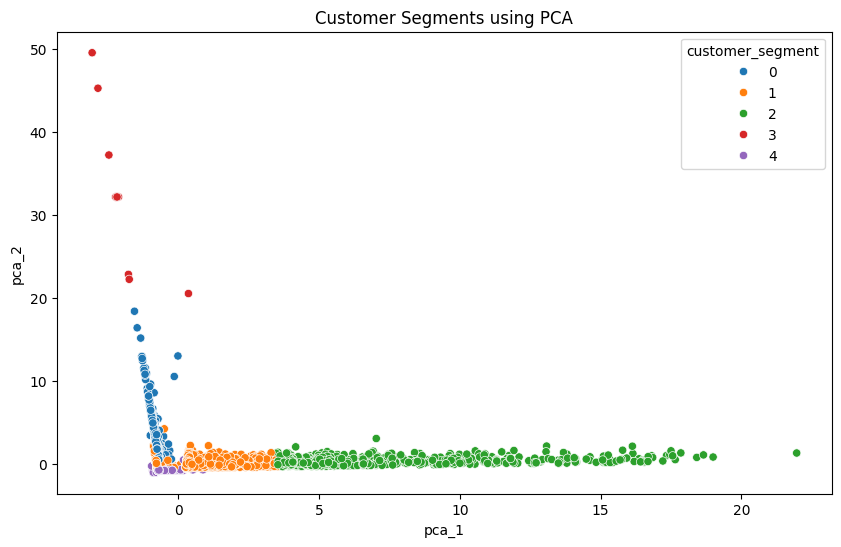

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=seg_df.sample(10000, random_state=42),
    x="pca_1",
    y="pca_2",
    hue="customer_segment",
    palette="tab10"
)
plt.title("Customer Segments using PCA")
plt.show()

In [18]:
sample_df = seg_df.sample(min(10000, len(seg_df)), random_state=42)

In [19]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(kmeans, "../models/customer_segmentation_model.pkl")
joblib.dump(scaler, "../models/customer_segmentation_scaler.pkl")
joblib.dump(pca, "../models/customer_segmentation_pca.pkl")

print("Segmentation model, scaler, and PCA saved successfully!")

Segmentation model, scaler, and PCA saved successfully!


In [20]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(kmeans, "../models/customer_segmentation_model.pkl")
joblib.dump(scaler, "../models/customer_segmentation_scaler.pkl")
joblib.dump(pca, "../models/customer_segmentation_pca.pkl")

print("Segmentation model, scaler, and PCA saved successfully!")

Segmentation model, scaler, and PCA saved successfully!


In [20]:
customer_features["total_transactions"].value_counts().head(10)

total_transactions
1    6344009
2       9283
3         15
Name: count, dtype: int64

In [22]:
fraud_df["nameDest"].value_counts().head(20)

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C1789550256     99
C451111351      99
C1360767589     98
C1023714065     97
C97730845       96
C977993101      96
C392292416      95
C1899073220     92
C306206744      91
C1782113663     90
C1234776885     90
C998351292      89
C716083600      89
C909295153      88
Name: count, dtype: int64